# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


# Project Milestone Two: Data Preparation and Model Exploration

**Team Members:** Jalini M Rajapakse & Timothy Levash

**Dataset Chosen:** HuffPost News Category Dataset  

**Task Type:** Multiclass Text Classification  


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




## Problem 1: Data Preparation and Splits

In this section, we prepare the HuffPost dataset for deep learning by cleaning the text, standardizing the inputs, creating reproducible train/validation/test splits, and checking class balance. The goal is to build a preprocessing pipeline that is clear, reproducible, and aligned with the issues identified in Milestone 1, especially class imbalance, duplicate records, missing text, and variation in text length.

In [3]:
# ============================================================
# Milestone 2 - Problem 1
# Setup and reproducibility
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

# Main preprocessing settings
MAX_TOKENS = 30000
MAX_LEN = 64
BATCH_SIZE = 128

print("Random seed:", RANDOM_SEED)
print("Max tokens :", MAX_TOKENS)
print("Max length :", MAX_LEN)
print("Batch size :", BATCH_SIZE)

Random seed: 42
Max tokens : 30000
Max length : 64
Batch size : 128


### Dataset Loading and Initial Inspection

We first load the HuffPost dataset from Hugging Face and inspect its structure, including the number of rows, feature names, and a sample entry. This confirms that the data match the expected format before any preprocessing begins.

In [4]:
# ============================================================
# Step 1: Load the HuffPost dataset
# ============================================================

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

example = huff_all[0]
print("\nOne example:")
print("category          :", example["category"])
print("headline          :", example["headline"])
print("short_description :", example["short_description"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853

One example:
category          : CRIME
headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
short_description : She left her husband. He killed their children. Just another day in America.


### Build a Clean Working Table

To make the preprocessing steps easier to follow, we convert the raw dataset into a pandas DataFrame and create a single combined text field using the headline and short description. Also clean basic formatting issues such as missing text values and extra whitespace so later steps will be consistent and easier to verify.

In [5]:
# ============================================================
# Step 2: Build a clean working DataFrame
# ============================================================

huff_df = pd.DataFrame({
    "category": huff_all["category"],
    "headline": huff_all["headline"],
    "short_description": huff_all["short_description"],
    "authors": huff_all["authors"],
    "date": huff_all["date"]
})

# Clean raw text fields
huff_df["headline"] = huff_df["headline"].fillna("").astype(str).str.strip()
huff_df["short_description"] = huff_df["short_description"].fillna("").astype(str).str.strip()

# Create the combined text field used for modeling
huff_df["text"] = huff_df["headline"] + " [SEP] " + huff_df["short_description"]

# A plain text version for empty-text checks
huff_df["text_for_check"] = (
    huff_df["headline"] + " " + huff_df["short_description"]
).str.replace(r"\s+", " ", regex=True).str.strip()

print("Shape of working DataFrame:", huff_df.shape)
display(huff_df.head())

Shape of working DataFrame: (200853, 7)


,category,headline,short_description,authors,date,text,text_for_check
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26,There Were 2 Mass Shootings In Texas Last Week...,There Were 2 Mass Shootings In Texas Last Week...
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26,Will Smith Joins Diplo And Nicky Jam For The 2...,Will Smith Joins Diplo And Nicky Jam For The 2...
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26,Hugh Grant Marries For The First Time At Age 5...,Hugh Grant Marries For The First Time At Age 5...
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Jim Carrey Blasts 'Castrato' Adam Schiff And D...
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26,Julianna Margulies Uses Donald Trump Poop Bags...,Julianna Margulies Uses Donald Trump Poop Bags...


### Cleaning Decisions

The cleaning step is intentionally conservative. We remove rows with no usable text and drop exact duplicate combined texts to reduce leakage risk, but we keep headline-only examples because a headline can still provide enough information for topic classification. This improves data quality without discarding more data than necessary.

In [6]:
# ============================================================
# Step 3: Cleaning and normalization
# ============================================================

initial_rows = len(huff_df)

empty_text_rows = (huff_df["text_for_check"].str.len() == 0).sum()
duplicate_text_rows = huff_df["text"].duplicated().sum()

print("Rows with no usable text :", empty_text_rows)
print("Exact duplicate texts    :", duplicate_text_rows)

# Remove rows with no usable text
huff_df = huff_df[huff_df["text_for_check"].str.len() > 0].copy()

# Remove exact duplicate combined texts
huff_df = huff_df.drop_duplicates(subset="text").copy()

# Reset index after cleaning
huff_df = huff_df.reset_index(drop=True)

print("\nRows before cleaning:", initial_rows)
print("Rows after cleaning :", len(huff_df))
print("Rows removed        :", initial_rows - len(huff_df))

Rows with no usable text : 5
Exact duplicate texts    : 488

Rows before cleaning: 200853
Rows after cleaning : 200364
Rows removed        : 489


### Encode Labels for Modeling

Because the model needs numerical targets, we convert the category labels into integer IDs while keeping a mapping back to the original topic names. This makes the labels usable for training without losing interpretability.

In [7]:
# ============================================================
# Step 4: Encode labels
# ============================================================

label_names = sorted(huff_df["category"].unique())
label_to_id = {label: idx for idx, label in enumerate(label_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

huff_df["label"] = huff_df["category"].map(label_to_id)

print("Number of classes:", len(label_names))
print("First 10 labels  :", label_names[:10])

display(huff_df[["category", "label", "headline"]].head())

Number of classes: 41
First 10 labels  : ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION']


,category,label,headline
0,CRIME,6,There Were 2 Mass Shootings In Texas Last Week...
1,ENTERTAINMENT,10,Will Smith Joins Diplo And Nicky Jam For The 2...
2,ENTERTAINMENT,10,Hugh Grant Marries For The First Time At Age 57
3,ENTERTAINMENT,10,Jim Carrey Blasts 'Castrato' Adam Schiff And D...
4,ENTERTAINMENT,10,Julianna Margulies Uses Donald Trump Poop Bags...


### Class Distribution After Cleaning

The cleaned dataset remains imbalanced, so we re-check the label counts after cleaning. This matters because later model evaluation should not rely on accuracy alone when some categories are much larger than others.

Largest class     : 32721
Smallest class    : 1004
Median class size : 3401
Imbalance ratio   : 9.62

Top 10 largest categories:


,count
category,
POLITICS,32721
WELLNESS,17821
ENTERTAINMENT,16054
TRAVEL,9883
STYLE & BEAUTY,9514
PARENTING,8649
HEALTHY LIVING,6689
QUEER VOICES,6310
FOOD & DRINK,6225



Top 10 smallest categories:


,count
category,
MONEY,1706
ARTS,1509
FIFTY,1401
GOOD NEWS,1398
ARTS & CULTURE,1338
ENVIRONMENT,1322
COLLEGE,1144
LATINO VOICES,1129
CULTURE & ARTS,1029


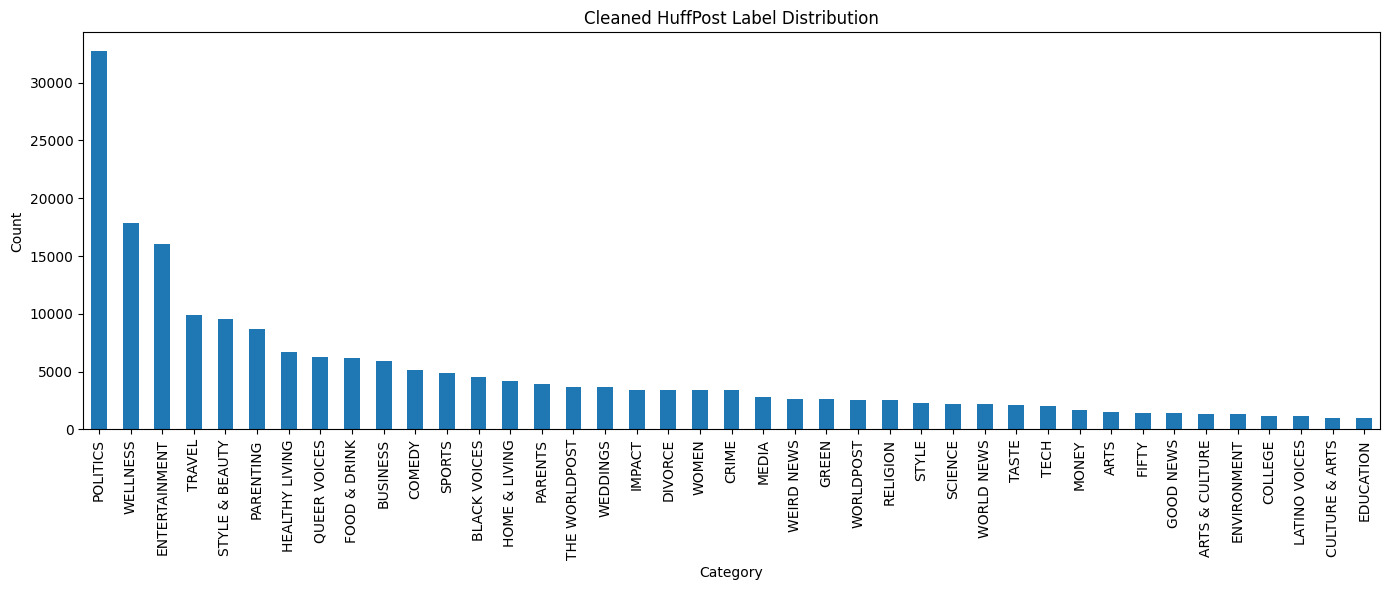

In [8]:
# ============================================================
# Step 5: Class distribution after cleaning
# ============================================================

label_counts = huff_df["category"].value_counts().sort_values(ascending=False)

largest_class = label_counts.max()
smallest_class = label_counts.min()
median_class = label_counts.median()
imbalance_ratio = largest_class / median_class

print("Largest class     :", largest_class)
print("Smallest class    :", smallest_class)
print("Median class size :", int(median_class))
print("Imbalance ratio   :", round(imbalance_ratio, 2))

print("\nTop 10 largest categories:")
display(label_counts.head(10))

print("\nTop 10 smallest categories:")
display(label_counts.tail(10))

plt.figure(figsize=(14, 6))
label_counts.plot(kind="bar")
plt.title("Cleaned HuffPost Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Text Length Analysis

The Milestone 1 EDA showed that HuffPost texts are generally short, but not all the same length. We re-check that pattern after cleaning so that the later max-length choice is based on the cleaned dataset rather than on the raw version.

Word count summary:
count    200364.000000
mean         30.274865
std          14.052512
min           2.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: word_count, dtype: float64

Key percentiles:
50th percentile: 29
75th percentile: 36
90th percentile: 50
95th percentile: 57
99th percentile: 68


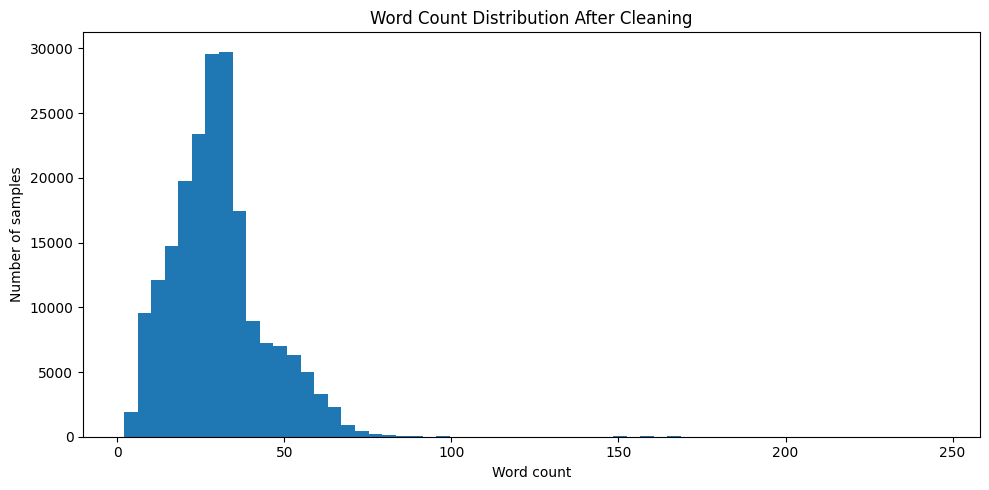

In [9]:
# ============================================================
# Step 6: Text-length analysis after cleaning
# ============================================================

huff_df["word_count"] = huff_df["text"].str.split().str.len()

print("Word count summary:")
print(huff_df["word_count"].describe())

print("\nKey percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", int(np.percentile(huff_df["word_count"], p)))

plt.figure(figsize=(10, 5))
plt.hist(huff_df["word_count"], bins=60)
plt.title("Word Count Distribution After Cleaning")
plt.xlabel("Word count")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

### Candidate Sequence Lengths

To make the max-length decision more evidence-based, we estimate how many records would be truncated at a few reasonable candidate lengths. A shorter sequence length is more efficient, but it should still preserve most of the useful text.

In [10]:
# ============================================================
# Step 7: Candidate sequence lengths
# ============================================================

candidate_lengths = [32, 64, 96, 128]

print("Estimated truncation rates")
for max_len in candidate_lengths:
    trunc_rate = (huff_df["word_count"] > max_len).mean() * 100
    print(f"max_length = {max_len:>3}: {trunc_rate:6.2f}% would be truncated")

Estimated truncation rates
max_length =  32:  36.69% would be truncated
max_length =  64:   1.61% would be truncated
max_length =  96:   0.11% would be truncated
max_length = 128:   0.08% would be truncated


### Reproducible Train, Validation, and Test Splits

We use an 80/10/10 split with a fixed random seed and stratification on the labels. Stratified splitting is especially important here because the dataset is imbalanced, so each subset should preserve the overall class distribution as much as possible.

In [11]:
# ============================================================
# Step 8: Stratified train / validation / test split
# ============================================================

train_df, temp_df = train_test_split(
    huff_df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=huff_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["label"]
)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))

Train size: 160291
Val size  : 20036
Test size : 20037


### Leakage Check

After splitting the data, we check for exact text overlap across the train, validation, and test sets. This is a simple but important quality-control step because duplicate records can otherwise inflate performance unfairly.

In [12]:
# ============================================================
# Step 9: Leakage checks
# ============================================================

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

train_val_overlap = len(train_texts.intersection(val_texts))
train_test_overlap = len(train_texts.intersection(test_texts))
val_test_overlap = len(val_texts.intersection(test_texts))

print("Exact text overlap checks")
print("Train / Val overlap :", train_val_overlap)
print("Train / Test overlap:", train_test_overlap)
print("Val / Test overlap  :", val_test_overlap)

Exact text overlap checks
Train / Val overlap : 0
Train / Test overlap: 0
Val / Test overlap  : 0


### Text Standardization and Tokenization

To prepare the text for deep learning, we use a Keras `TextVectorization` layer to standardize, tokenize, and convert the combined text into fixed-length integer sequences. This keeps the pipeline reproducible and integrates well with TensorFlow.

In [13]:
# ============================================================
# Step 10: Text vectorization
# ============================================================

vectorize = tf.keras.layers.TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

vectorize.adapt(train_df["text"].values)

vocab = vectorize.get_vocabulary()
print("Vocabulary size learned:", len(vocab))
print("First 20 tokens:", vocab[:20])
print("Sequence length:", MAX_LEN)

Vocabulary size learned: 30000
First 20 tokens: ['', '[UNK]', np.str_('the'), np.str_('sep'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('and'), np.str_('in'), np.str_('is'), np.str_('for'), np.str_('that'), np.str_('on'), np.str_('you'), np.str_('with'), np.str_('i'), np.str_('it'), np.str_('are'), np.str_('this'), np.str_('be')]
Sequence length: 64


### Checking the Preprocessed Output

Before moving on, we display a few representative examples after vectorization to confirm that the transformations behave as expected. This helps verify both the shape of the input and the overall consistency of the preprocessing pipeline.

In [14]:
# ============================================================
# Step 11: Representative preprocessed examples
# ============================================================

sample_rows = train_df[["category", "text"]].head(3)

for _, row in sample_rows.iterrows():
    token_ids = vectorize(tf.constant([row["text"]])).numpy()[0]

    print("\nCategory:", row["category"])
    print("Original text:")
    print(row["text"][:250], "..." if len(row["text"]) > 250 else "")
    print("Vectorized shape:", token_ids.shape)
    print("First 20 token IDs:", token_ids[:20])


Category: PARENTING
Original text:
Top 9 Worst Ways to Explain To Your Kids Where Babies Come From [SEP] 2. Show them the video of their own births. It’s the question every parent dreads: "Mom, where do babies come from?" If you’re 
Vectorized shape: (64,)
First 20 token IDs: [ 198  615  568  160    4 1518    4   20  116  144 1072  211   24    3
  356  147  102    2   85    6]

Category: WELLNESS
Original text:
God Whispered [SEP] Why me, why now, I thought. Why is life so hard? That's when God whispered something in my head. I want to share it with 
Vectorized shape: (64,)
First 20 token IDs: [ 1052 14765     3    71    78    71    86    15   371    71     9    74
    64   326   254    45  1052 14765   168     8]

Category: POLITICS
Original text:
The Supreme Court Stays Keith Tharpe's Execution At The Last Minute [SEP] Critically important decisions about who gets to live and who dies are being made — often along racial lines — by an almost uniformly white group of prosecutors. 
Vec

### Build TensorFlow Datasets

The final preprocessing step is to package the inputs and labels into TensorFlow datasets so they are ready for batching, shuffling, and model training. This makes the pipeline easier to reuse in the modeling section of the notebook.

In [15]:
# ============================================================
# Step 12: Build tf.data datasets
# ============================================================

def make_text_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df["text"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=RANDOM_SEED)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (vectorize(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_text_dataset(train_df, shuffle=True)
val_ds = make_text_dataset(val_df, shuffle=False)
test_ds = make_text_dataset(test_df, shuffle=False)

print("Prepared tf.data datasets:")
print("train_ds:", train_ds)
print("val_ds  :", val_ds)
print("test_ds :", test_ds)

Prepared tf.data datasets:
train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
val_ds  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
test_ds : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


### Class Weights

Because the HuffPost labels are imbalanced, we compute class weights from the training set. This is a practical first step for helping minority classes carry more influence during model fitting without changing the original data distribution.

In [16]:
# ============================================================
# Step 13: Compute class weights
# ============================================================

classes = np.array(sorted(train_df["label"].unique()))
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print("First 10 class weights:")
for cls_id in list(class_weight_dict.keys())[:10]:
    print(f"{cls_id:>2} ({id_to_label[cls_id]}): {class_weight_dict[cls_id]:.3f}")

First 10 class weights:
 0 (ARTS): 3.239
 1 (ARTS & CULTURE): 3.650
 2 (BLACK VOICES): 1.081
 3 (BUSINESS): 0.824
 4 (COLLEGE): 4.273
 5 (COMEDY): 0.946
 6 (CRIME): 1.437
 7 (CULTURE & ARTS): 4.750
 8 (DIVORCE): 1.428
 9 (EDUCATION): 4.869


### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



**1.1:**

WE loaded the HuffPost News Category dataset from Hugging Face using datasets.load_dataset(), then reviewed its structure by checking the feature names, total number of rows, and a representative example entry. The raw dataset contained 200,853 rows with the expected text fields, including headline, short_description, and category. To prepare the data for modeling, we converted the dataset into a pandas DataFrame, cleaned the text fields by filling missing values and stripping extra whitespace, and combined the headline and short description into a single text field. We then removed rows with no usable text and dropped exact duplicate combined texts. This reduced the dataset from 200,853 rows to 200,364 rows, meaning 489 rows were removed during cleaning. We kept headline-only examples because a headline can still provide enough information for topic classification, so the cleaning process focused on improving quality without discarding more data than necessary.




2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

**1.2:**

Our preprocessing pipeline was designed to be simple, reproducible, and appropriate for a deep-learning text model. After building the combined text field in the format headline [SEP] short_description, we used a Keras TextVectorization layer to standardize and tokenize the text. The layer lowercases the text, strips punctuation, converts tokens into integer IDs, and produces fixed-length sequences for modeling. We set the vocabulary size to 30,000 tokens and used a maximum sequence length of 64, based on the earlier Milestone 1 length analysis and the cleaned-data truncation results. The output confirmed that 64 tokens preserves almost all records, with only 1.61% of examples requiring truncation. Then packaged the processed text and labels into TensorFlow datasets for the train, validation, and test sets so the data are ready for reproducible model training in Keras.



3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


**1.3:**

We divided the cleaned dataset into train, validation, and test subsets using an 80/10/10 split with a fixed random seed of 42. To make the split reproducible and preserve the class distribution across all subsets, We used stratified splitting based on the encoded labels. This produced 160,291 training examples, 20,036 validation examples, and 20,037 test examples. After splitting, We performed a leakage check by testing for exact text overlap across the three subsets. The results showed 0 overlapping texts between train and validation, train and test, and validation and test, which confirms that the cleaning and deduplication steps were effective and that the evaluation sets are not contaminated by duplicate examples from training.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


**1.4:**

The cleaned HuffPost dataset remains clearly imbalanced. After cleaning, the largest class contained 32,721 examples, while the smallest class contained 1,004, with a median class size of 3,401, producing an imbalance ratio of 9.62. The largest category is still Politics, while smaller categories such as Education, Culture & Arts, and Arts & Culture remain much less frequent. Because of this imbalance, We did not want later model evaluation to rely only on accuracy, since dominant categories could inflate the score. To address the imbalance during training, we computed class weights from the training set so that minority categories would carry more influence during model fitting. The resulting weights confirm the imbalance clearly, with larger weights assigned to rare categories such as Education and Culture & Arts and smaller weights assigned to more common categories.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

## Problem 2: Baseline Model

In this section, we build and train a small embedding-based baseline model for the HuffPost dataset. The goal is to establish a clear reference point before trying more complex architectures later in the milestone. We keep the model intentionally simple so that it trains quickly, remains easy to interpret, and provides a fair benchmark for future improvements.

In [17]:
# ============================================================
# Problem 2 - Baseline model
# Quick setup check
# ============================================================

required_objects = [
    "train_df", "val_df", "test_df",
    "train_ds", "val_ds", "test_ds",
    "label_names", "MAX_TOKENS", "MAX_LEN", "BATCH_SIZE",
    "class_weight_dict"
]

missing = [name for name in required_objects if name not in globals()]

if missing:
    print("Missing objects from Problem 1:")
    print(missing)
    raise ValueError("Please run Problem 1 cells before starting Problem 2.")
else:
    print("All required Problem 1 objects are available.")
    print("Number of classes:", len(label_names))

All required Problem 1 objects are available.
Number of classes: 41


### Baseline Design

For a first text baseline, we use a small embedding-based classifier. This model maps each token to a learned embedding, averages those embeddings across the sequence, and then applies a small dense classifier. The design is intentionally compact so that it can train in minutes on Colab while still learning useful signal from the text.

In [18]:
# ============================================================
# Step 1: Build a small baseline text model
# ============================================================

from tensorflow.keras import layers, models

EMBED_DIM = 64
HIDDEN_UNITS = 64
DROPOUT_RATE = 0.30

baseline_model = models.Sequential([
    layers.Input(shape=(MAX_LEN,), name="token_ids"),
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM, name="embedding"),
    layers.GlobalAveragePooling1D(name="avg_pool"),
    layers.Dropout(DROPOUT_RATE, name="dropout"),
    layers.Dense(HIDDEN_UNITS, activation="relu", name="dense_relu"),
    layers.Dense(len(label_names), activation="softmax", name="classifier")
])

baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 64, 64)            1920000   
                                                                 
 avg_pool (GlobalAveragePoo  (None, 64)                0         
 ling1D)                                                         
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_relu (Dense)          (None, 64)                4160      
                                                                 
 classifier (Dense)          (None, 41)                2665      
                                                                 
Total params: 1926825 (7.35 MB)
Trainable params: 1926825 (7.35 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

### Compile the Model

The model is compiled with the Adam optimizer and sparse categorical cross-entropy. We use the sparse version of the loss because the labels are integer-encoded rather than one-hot encoded. Accuracy is tracked during training, and macro-F1 will be computed afterward from the validation and test predictions since that metric is especially important for this imbalanced dataset.

In [19]:
# ============================================================
# Step 2: Compile the model
# ============================================================

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### Training Setup

We use early stopping on validation loss with a patience of 5 epochs and restore the best weights at the end of training. This keeps the training efficient and helps reduce unnecessary overfitting once validation performance stops improving.

In [20]:
# ============================================================
# Step 3: Training setup
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

EPOCHS = 20
print("Epochs:", EPOCHS)

Epochs: 20


In [22]:
# ============================================================
# Step 4: Train the baseline model
# ============================================================

start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

runtime_sec = time.time() - start_time
epochs_trained = len(baseline_history.history["loss"])

print(f"\nTraining complete in {runtime_sec:.2f} seconds")
print("Epochs trained:", epochs_trained)

Epoch 1/20
1253/1253 [==============================] - 45s 34ms/step - loss: 3.2482 - accuracy: 0.1650 - val_loss: 2.6541 - val_accuracy: 0.2807
Epoch 2/20
1253/1253 [==============================] - 8s 6ms/step - loss: 2.4465 - accuracy: 0.3588 - val_loss: 2.1616 - val_accuracy: 0.4350
Epoch 3/20
1253/1253 [==============================] - 7s 6ms/step - loss: 2.0002 - accuracy: 0.4618 - val_loss: 1.9876 - val_accuracy: 0.4656
Epoch 4/20
1253/1253 [==============================] - 6s 5ms/step - loss: 1.7092 - accuracy: 0.5146 - val_loss: 1.8560 - val_accuracy: 0.5033
Epoch 5/20
1253/1253 [==============================] - 6s 4ms/step - loss: 1.5118 - accuracy: 0.5538 - val_loss: 1.8452 - val_accuracy: 0.5017
Epoch 6/20
1253/1253 [==============================] - 6s 5ms/step - loss: 1.3542 - accuracy: 0.5818 - val_loss: 1.7977 - val_accuracy: 0.5216
Epoch 7/20
1253/1253 [==============================] - 4s 3ms/step - loss: 1.2305 - accuracy: 0.6067 - val_loss: 1.7967 - val_accurac

### Training Curves

The next plots compare training and validation loss and accuracy across epochs. These curves help show whether the model is underfitting, overfitting, or generalizing reasonably well.

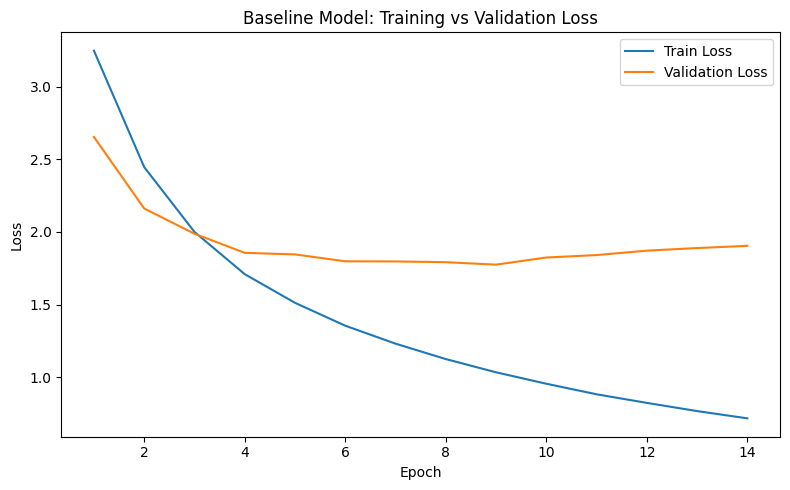

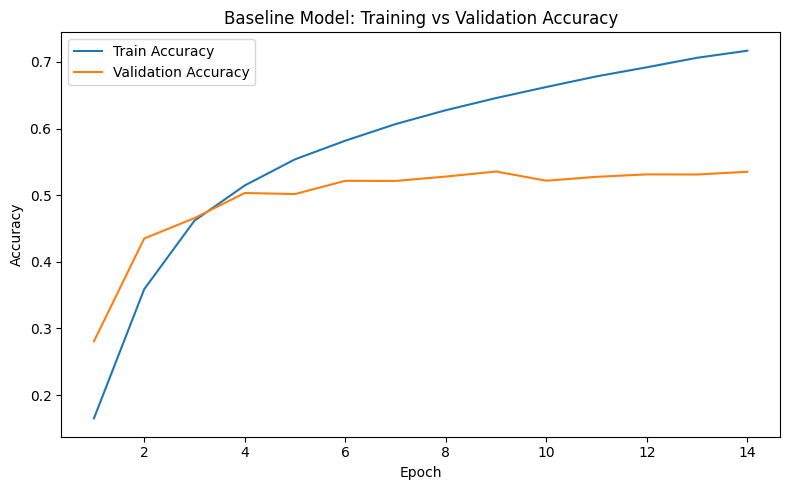

In [23]:
# ============================================================
# Step 5: Plot training history
# ============================================================

history_df = pd.DataFrame(baseline_history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["loss"], label="Train Loss")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model: Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model: Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Best Validation Epoch

For this milestone, the most important benchmark is the validation accuracy at the epoch with the minimum validation loss. We extract that value directly so it can be used as the baseline reference for later experiments.

In [24]:
# ============================================================
# Step 6: Best validation epoch summary
# ============================================================

best_epoch = int(np.argmin(history_df["val_loss"])) + 1
best_val_loss = float(history_df["val_loss"].min())
best_val_acc = float(history_df.loc[best_epoch - 1, "val_accuracy"])

print("Best epoch (by minimum validation loss):", best_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc:.4f}")

Best epoch (by minimum validation loss): 9
Best validation loss: 1.7746
Validation accuracy at best epoch: 0.5355


### Validation and Test Metrics

We evaluate the model on the test set and also compute macro-F1 from the validation and test predictions. Accuracy is useful as a general baseline metric, but macro-F1 is especially important here because the category distribution is imbalanced.

In [25]:
# ============================================================
# Step 7: Validation and test metrics
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Validation predictions
val_probs = baseline_model.predict(val_ds, verbose=0)
val_pred = np.argmax(val_probs, axis=1)
val_true = val_df["label"].to_numpy()

val_accuracy = accuracy_score(val_true, val_pred)
val_macro_f1 = f1_score(val_true, val_pred, average="macro")

# Test predictions
test_probs = baseline_model.predict(test_ds, verbose=0)
test_pred = np.argmax(test_probs, axis=1)
test_true = test_df["label"].to_numpy()

test_accuracy = accuracy_score(test_true, test_pred)
test_macro_f1 = f1_score(test_true, test_pred, average="macro")

# Also collect test loss / accuracy from model.evaluate
test_loss, test_acc_eval = baseline_model.evaluate(test_ds, verbose=0)

print("Validation metrics")
print(f"Validation accuracy : {val_accuracy:.4f}")
print(f"Validation macro-F1 : {val_macro_f1:.4f}")

print("\nTest metrics")
print(f"Test loss           : {test_loss:.4f}")
print(f"Test accuracy       : {test_accuracy:.4f}")
print(f"Test macro-F1       : {test_macro_f1:.4f}")

Validation metrics
Validation accuracy : 0.5355
Validation macro-F1 : 0.4582

Test metrics
Test loss           : 1.7512
Test accuracy       : 0.5477
Test macro-F1       : 0.4679


In [26]:
# ============================================================
# Step 8: Compact results summary
# ============================================================

baseline_results = pd.DataFrame([{
    "epochs_trained": epochs_trained,
    "runtime_sec": round(runtime_sec, 2),
    "best_epoch_by_val_loss": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "val_accuracy_at_best_loss": round(best_val_acc, 4),
    "val_macro_f1": round(val_macro_f1, 4),
    "test_loss": round(test_loss, 4),
    "test_accuracy": round(test_accuracy, 4),
    "test_macro_f1": round(test_macro_f1, 4)
}])

display(baseline_results)

,epochs_trained,runtime_sec,best_epoch_by_val_loss,best_val_loss,val_accuracy_at_best_loss,val_macro_f1,test_loss,test_accuracy,test_macro_f1
0,14,115.52,9,1.7746,0.5355,0.4582,1.7512,0.5477,0.4679


In [27]:
# ============================================================
# Step 9: Brief class-level report
# ============================================================

print("Test classification report (first part):")
report = classification_report(
    test_true,
    test_pred,
    target_names=label_names,
    zero_division=0
)
print(report[:3000])   # print the first part so the output stays manageable

Test classification report (first part):
                precision    recall  f1-score   support

          ARTS       0.28      0.43      0.34       151
ARTS & CULTURE       0.23      0.40      0.30       133
  BLACK VOICES       0.43      0.45      0.44       453
      BUSINESS       0.45      0.42      0.43       594
       COLLEGE       0.28      0.46      0.35       114
        COMEDY       0.47      0.41      0.44       517
         CRIME       0.43      0.62      0.51       340
CULTURE & ARTS       0.34      0.55      0.42       103
       DIVORCE       0.75      0.74      0.75       342
     EDUCATION       0.25      0.55      0.34       100
 ENTERTAINMENT       0.70      0.52      0.60      1606
   ENVIRONMENT       0.26      0.54      0.35       132
         FIFTY       0.15      0.36      0.21       140
  FOOD & DRINK       0.64      0.61      0.63       623
     GOOD NEWS       0.18      0.31      0.23       139
         GREEN       0.33      0.29      0.31       261
HEALTH

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

**2.1:**

Our baseline model was a small embedding-based text classifier built with the structure `Embedding → GlobalAveragePooling1D → Dropout → Dense → Softmax`. We chose this design because it gives a simple, fast, and fully working starting point before moving on to more advanced models. The embedding layer learns a dense representation of the tokenized text, the global average pooling layer reduces each sequence to a compact summary, and the dense layers map that summary to one of the 41 topic categories. We also included dropout to add a basic level of regularization without making the model unnecessarily complex. Overall, this model worked well as a baseline because it let us test the preprocessing pipeline and establish a clear reference point for comparison.



2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

**2.2:**

The training and validation curves show that the baseline model learned useful signal from the dataset, especially during the early and middle epochs. Its best validation loss occurred at epoch 9, where the validation accuracy reached 0.5355. After that point, the model still continued training, but the validation improvement became smaller, which suggests that it was starting to level off and may have been moving toward mild overfitting. Even so, the overall training behavior was stable, and the model did not show erratic jumps or obvious failure. That is a good outcome for a baseline model, since its main job is to give a reliable benchmark rather than solve the whole problem.


  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

**2.3:**

At its best validation point, the baseline model achieved a validation accuracy of 0.5355 and a validation macro-F1 of 0.4582. On the test set, it reached an accuracy of 0.5477 and a macro-F1 of 0.4679. These results show that the model was learning real topic patterns and performing much better than random guessing, which is encouraging given that this is a 41-class classification task. At the same time, the macro-F1 score is lower than the accuracy, which suggests that the model still struggled to perform evenly across the smaller and more difficult categories. So the baseline gave us a solid starting point, but it also showed that there was still room for improvement.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

**2.4:**

The main limitation of the baseline is that it treats the sequence in a very simple way by averaging token embeddings, so it cannot fully capture word order, longer dependencies, or more subtle contextual meaning. That makes it efficient and easy to train, but it also limits how much it can learn from short news text where small wording differences can change the category. In other words, it works well as a benchmark, but it is not strong enough to fully handle a dataset with overlapping labels and class imbalance. Based on that result, the most natural next step was to try a stronger sequence model and then compare that with a pretrained transformer-based approach later in the milestone.



## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

## Problem 3: Custom (Original) Model

In this section, we build a custom text model that extends the baseline in a meaningful way. The baseline model was able to learn useful signal from the HuffPost dataset, but its architecture was intentionally simple and likely limited by the way it compresses the text into a single average embedding. To address that limitation,we design a stronger sequence model that can better capture word order and short-range context while still remaining practical to train on Colab.

In [28]:
# ============================================================
# Problem 3 - Custom model
# Quick setup check
# ============================================================

required_objects = [
    "train_df", "val_df", "test_df",
    "train_ds", "val_ds", "test_ds",
    "label_names", "MAX_TOKENS", "MAX_LEN", "BATCH_SIZE",
    "class_weight_dict", "baseline_results"
]

missing = [name for name in required_objects if name not in globals()]

if missing:
    print("Missing objects from earlier sections:")
    print(missing)
    raise ValueError("Please run Problem 1 and Problem 2 before starting Problem 3.")
else:
    print("All required objects are available.")
    print("Number of classes:", len(label_names))

All required objects are available.
Number of classes: 41


### Model Design Rationale

The baseline model used an embedding layer followed by global average pooling, which made it fast and effective as a first benchmark but also limited its ability to capture sequence order and contextual relationships. In this custom model, we replace the pooling step with a **bidirectional GRU** so the network can learn from token order in both directions. we also add **SpatialDropout1D** to regularize the embedding sequence more directly and reduce overfitting.

In [29]:
# ============================================================
# Step 1: Build a stronger custom text model
# ============================================================

from tensorflow.keras import layers, models

CUSTOM_EMBED_DIM = 96
GRU_UNITS = 64
SPATIAL_DROPOUT_RATE = 0.20
DENSE_UNITS = 64
DROPOUT_RATE = 0.30

custom_model = models.Sequential([
    layers.Input(shape=(MAX_LEN,), name="token_ids"),
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=CUSTOM_EMBED_DIM,
        name="embedding"
    ),
    layers.SpatialDropout1D(SPATIAL_DROPOUT_RATE, name="spatial_dropout"),
    layers.Bidirectional(
        layers.GRU(GRU_UNITS),
        name="bidirectional_gru"
    ),
    layers.Dropout(DROPOUT_RATE, name="dropout"),
    layers.Dense(DENSE_UNITS, activation="relu", name="dense_relu"),
    layers.Dense(len(label_names), activation="softmax", name="classifier")
])

custom_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 64, 96)            2880000   
                                                                 
 spatial_dropout (SpatialDr  (None, 64, 96)            0         
 opout1D)                                                        
                                                                 
 bidirectional_gru (Bidirec  (None, 128)               62208     
 tional)                                                         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_relu (Dense)          (None, 64)                8256      
                                                                 
 classifier (Dense)          (None, 41)               

### Why This Modification Should Help

This custom model is designed to address one of the main limitations of the baseline: the loss of sequential information. A bidirectional recurrent layer should be better able to capture phrases, ordering, and context that matter for separating related HuffPost categories. The added spatial dropout is meant to regularize the sequence representation and improve generalization.

In [34]:
# ============================================================
# Step 2: Compile the custom model
# ============================================================

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Custom model compiled successfully.")

Custom model compiled successfully.


### Training Setup

To keep this experiment comparable to the baseline, we use the same data splits, random seed, class weights, and evaluation metrics. We also keep early stopping on validation loss so that the custom model is trained under the same general conditions.

In [35]:
# ============================================================
# Step 3: Training setup
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping

custom_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

CUSTOM_EPOCHS = 20
print("Epochs:", CUSTOM_EPOCHS)

Epochs: 20


In [36]:
# ============================================================
# Step 4: Train the custom model
# ============================================================

start_time = time.time()

custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CUSTOM_EPOCHS,
    callbacks=[custom_early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

custom_runtime_sec = time.time() - start_time
custom_epochs_trained = len(custom_history.history["loss"])

print(f"\nTraining complete in {custom_runtime_sec:.2f} seconds")
print("Epochs trained:", custom_epochs_trained)

Epoch 1/20
1253/1253 [==============================] - 56s 42ms/step - loss: 2.7574 - accuracy: 0.2885 - val_loss: 2.1128 - val_accuracy: 0.4239
Epoch 2/20
1253/1253 [==============================] - 18s 14ms/step - loss: 1.8283 - accuracy: 0.4783 - val_loss: 1.8052 - val_accuracy: 0.5020
Epoch 3/20
1253/1253 [==============================] - 13s 10ms/step - loss: 1.4536 - accuracy: 0.5541 - val_loss: 1.7549 - val_accuracy: 0.5165
Epoch 4/20
1253/1253 [==============================] - 13s 10ms/step - loss: 1.2369 - accuracy: 0.5958 - val_loss: 1.7336 - val_accuracy: 0.5264
Epoch 5/20
1253/1253 [==============================] - 13s 10ms/step - loss: 1.0723 - accuracy: 0.6265 - val_loss: 1.7899 - val_accuracy: 0.5204
Epoch 6/20
1253/1253 [==============================] - 12s 10ms/step - loss: 0.9478 - accuracy: 0.6517 - val_loss: 1.8542 - val_accuracy: 0.5136
Epoch 7/20
1253/1253 [==============================] - 13s 10ms/step - loss: 0.8417 - accuracy: 0.6772 - val_loss: 1.8712 -

### Training Curves

The next plots compare training and validation loss and accuracy over time. These curves help show whether the custom model is converging more smoothly than the baseline and whether the architectural changes improved generalization or only increased model capacity.

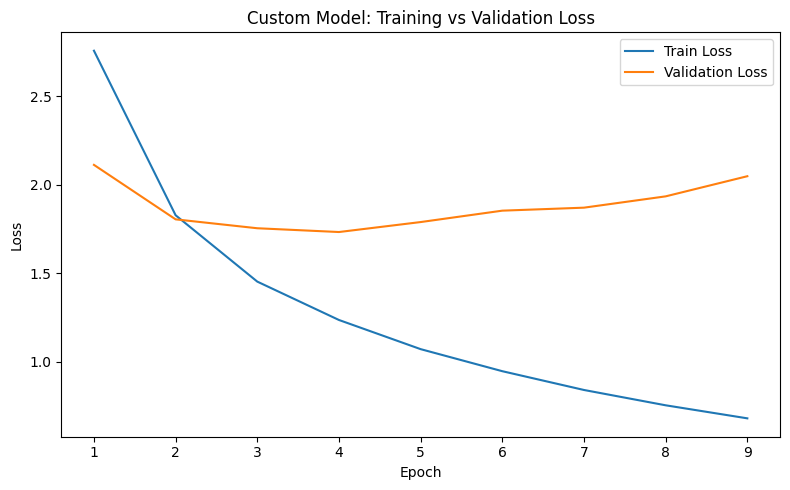

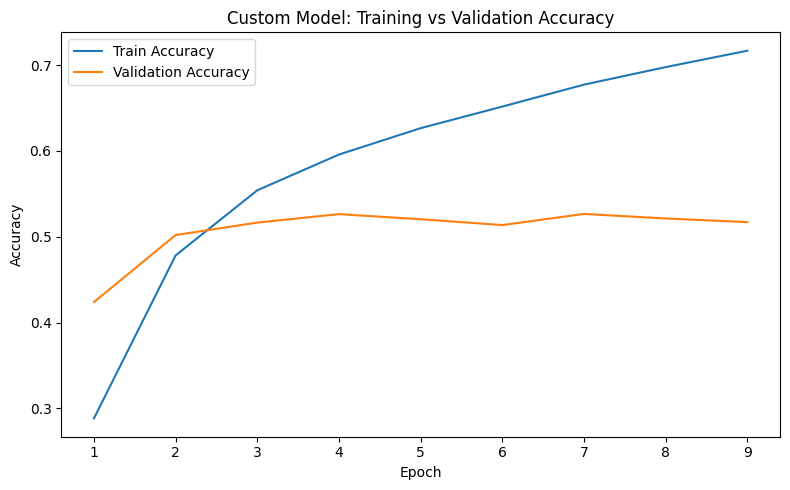

In [37]:
# ============================================================
# Step 5: Plot training history
# ============================================================

custom_history_df = pd.DataFrame(custom_history.history)

plt.figure(figsize=(8, 5))
plt.plot(custom_history_df.index + 1, custom_history_df["loss"], label="Train Loss")
plt.plot(custom_history_df.index + 1, custom_history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom Model: Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(custom_history_df.index + 1, custom_history_df["accuracy"], label="Train Accuracy")
plt.plot(custom_history_df.index + 1, custom_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom Model: Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Best Validation Epoch

As in the baseline section, the key benchmark is the validation accuracy at the epoch with the minimum validation loss. This keeps the comparison across models consistent.

In [38]:
# ============================================================
# Step 6: Best validation epoch summary
# ============================================================

custom_best_epoch = int(np.argmin(custom_history_df["val_loss"])) + 1
custom_best_val_loss = float(custom_history_df["val_loss"].min())
custom_best_val_acc = float(custom_history_df.loc[custom_best_epoch - 1, "val_accuracy"])

print("Best epoch (by minimum validation loss):", custom_best_epoch)
print(f"Best validation loss: {custom_best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {custom_best_val_acc:.4f}")

Best epoch (by minimum validation loss): 4
Best validation loss: 1.7336
Validation accuracy at best epoch: 0.5264


### Validation and Test Metrics

We evaluate the custom model on the validation and test sets using the same metrics as the baseline, including accuracy and macro-F1. This makes it easier to judge whether the added complexity actually improved performance.

In [39]:
# ============================================================
# Step 7: Validation and test metrics
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

# Validation predictions
custom_val_probs = custom_model.predict(val_ds, verbose=0)
custom_val_pred = np.argmax(custom_val_probs, axis=1)
custom_val_true = val_df["label"].to_numpy()

custom_val_accuracy = accuracy_score(custom_val_true, custom_val_pred)
custom_val_macro_f1 = f1_score(custom_val_true, custom_val_pred, average="macro")

# Test predictions
custom_test_probs = custom_model.predict(test_ds, verbose=0)
custom_test_pred = np.argmax(custom_test_probs, axis=1)
custom_test_true = test_df["label"].to_numpy()

custom_test_accuracy = accuracy_score(custom_test_true, custom_test_pred)
custom_test_macro_f1 = f1_score(custom_test_true, custom_test_pred, average="macro")

# Keras evaluate for loss / accuracy
custom_test_loss, custom_test_acc_eval = custom_model.evaluate(test_ds, verbose=0)

print("Validation metrics")
print(f"Validation accuracy : {custom_val_accuracy:.4f}")
print(f"Validation macro-F1 : {custom_val_macro_f1:.4f}")

print("\nTest metrics")
print(f"Test loss           : {custom_test_loss:.4f}")
print(f"Test accuracy       : {custom_test_accuracy:.4f}")
print(f"Test macro-F1       : {custom_test_macro_f1:.4f}")

Validation metrics
Validation accuracy : 0.5264
Validation macro-F1 : 0.4562

Test metrics
Test loss           : 1.7225
Test accuracy       : 0.5317
Test macro-F1       : 0.4581


In [40]:
# ============================================================
# Step 8: Compact custom-model results summary
# ============================================================

custom_results = pd.DataFrame([{
    "epochs_trained": custom_epochs_trained,
    "runtime_sec": round(custom_runtime_sec, 2),
    "best_epoch_by_val_loss": custom_best_epoch,
    "best_val_loss": round(custom_best_val_loss, 4),
    "val_accuracy_at_best_loss": round(custom_best_val_acc, 4),
    "val_macro_f1": round(custom_val_macro_f1, 4),
    "test_loss": round(custom_test_loss, 4),
    "test_accuracy": round(custom_test_accuracy, 4),
    "test_macro_f1": round(custom_test_macro_f1, 4)
}])

display(custom_results)

,epochs_trained,runtime_sec,best_epoch_by_val_loss,best_val_loss,val_accuracy_at_best_loss,val_macro_f1,test_loss,test_accuracy,test_macro_f1
0,9,163.14,4,1.7336,0.5264,0.4562,1.7225,0.5317,0.4581


### Compare the Custom Model to the Baseline

The final comparison should make it easy to see whether the custom model improved validation and test performance, whether it converged more stably, and whether the extra complexity was justified.

In [41]:
# ============================================================
# Step 9: Baseline vs custom comparison
# ============================================================

comparison_df = pd.DataFrame([
    {
        "model": "Baseline",
        "epochs_trained": int(baseline_results.loc[0, "epochs_trained"]),
        "runtime_sec": float(baseline_results.loc[0, "runtime_sec"]),
        "best_epoch_by_val_loss": int(baseline_results.loc[0, "best_epoch_by_val_loss"]),
        "best_val_loss": float(baseline_results.loc[0, "best_val_loss"]),
        "val_accuracy_at_best_loss": float(baseline_results.loc[0, "val_accuracy_at_best_loss"]),
        "val_macro_f1": float(baseline_results.loc[0, "val_macro_f1"]),
        "test_loss": float(baseline_results.loc[0, "test_loss"]),
        "test_accuracy": float(baseline_results.loc[0, "test_accuracy"]),
        "test_macro_f1": float(baseline_results.loc[0, "test_macro_f1"])
    },
    {
        "model": "Custom",
        "epochs_trained": custom_epochs_trained,
        "runtime_sec": round(custom_runtime_sec, 2),
        "best_epoch_by_val_loss": custom_best_epoch,
        "best_val_loss": round(custom_best_val_loss, 4),
        "val_accuracy_at_best_loss": round(custom_best_val_acc, 4),
        "val_macro_f1": round(custom_val_macro_f1, 4),
        "test_loss": round(custom_test_loss, 4),
        "test_accuracy": round(custom_test_accuracy, 4),
        "test_macro_f1": round(custom_test_macro_f1, 4)
    }
])

display(comparison_df)

,model,epochs_trained,runtime_sec,best_epoch_by_val_loss,best_val_loss,val_accuracy_at_best_loss,val_macro_f1,test_loss,test_accuracy,test_macro_f1
0,Baseline,14,115.52,9,1.7746,0.5355,0.4582,1.7512,0.5477,0.4679
1,Custom,9,163.14,4,1.7336,0.5264,0.4562,1.7225,0.5317,0.4581


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

**3.1:**

For our custom model, we replaced the baseline’s simple averaging step with a bidirectional GRU so the model could better capture word order and context. We also added 'SpatialDropout1D' to improve regularization. The goal was to address one of the baseline's main limitations: it was simple and efficient, but it likely lost too much sequential information. This custom design was meant to test whether a more expressive sequence model would improve classification performance while still staying manageable in Keras.



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

**3.2:**

The custom model reached its best validation loss at epoch 4. At that point, it achieved a validation accuracy of 0.5264 and a validation macro-F1 of 0.4562. On the test set, it achieved an accuracy of 0.5317 and a macro-F1 of 0.4581. Although the model was more advanced than the baseline, the final results were slightly weaker overall. The validation accuracy was still close, but the test accuracy and macro-F1 were both lower, so the added complexity did not turn into better generalization on this dataset.


3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

**3.3:**

What stands out most is that the custom model learned fairly quickly, but that early learning did not turn into stronger final performance. It found a reasonable validation point within only a few epochs, which suggests that it was able to pick up useful patterns. However, it still ended up slightly behind the baseline on the final test metrics. That tells us the problem was not simply that the baseline was too simple. A stronger sequence model was a reasonable idea, but in this case it was still not enough to overcome the overlap and imbalance in the dataset.


4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

**3.4:**

The main lesson from this experiment is that a more complex model is only helpful if it actually improves validation and test performance. In this case, the custom model was more expressive than the baseline, but it did not produce a meaningful gain. That makes the baseline comparison especially important, because it prevents us from assuming that a more advanced-looking architecture must automatically be better. Based on this result, the next step made more sense as a change in modeling strategy rather than simply adding more complexity to a scratch-trained network.



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


## Problem 4: Pretrained Model

In this section, we use transfer learning with a pretrained transformer model for the HuffPost text classification task. The goal is to test whether a model that already has strong language knowledge can improve validation and test performance compared with the baseline and custom models trained from scratch.

### Colab Setup

For this section, we use the Hugging Face `transformers` library to load a pretrained DistilBERT model. In Colab, we only need to run the setup step once. After the runtime restarts, we leave the setup flag turned off and run the notebook normally.

In [1]:
# ============================================================
# Problem 4 - Imports and environment check
# ============================================================

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tf_keras as keras
import transformers

from transformers import AutoTokenizer, TFDistilBertModel
from sklearn.metrics import accuracy_score, f1_score

print("TensorFlow version :", tf.__version__)
print("Transformers version:", transformers.__version__)
print("Legacy Keras mode  :", os.environ.get("TF_USE_LEGACY_KERAS"))
print("Setup complete.")

TensorFlow version : 2.19.0
Transformers version: 4.49.0
Legacy Keras mode  : 1
Setup complete.


In [42]:
RUN_COLAB_SETUP = False

### Imports and Environment Check

Before importing TensorFlow, we switch to legacy Keras mode so the Hugging Face TensorFlow classes work more smoothly in Colab.

In [43]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tf_keras as keras
import transformers

from transformers import AutoTokenizer, TFDistilBertModel
from sklearn.metrics import accuracy_score, f1_score

print("TensorFlow version :", tf.__version__)
print("Transformers version:", transformers.__version__)
print("Legacy Keras mode  :", os.environ.get("TF_USE_LEGACY_KERAS"))

TensorFlow version : 2.19.0
Transformers version: 4.49.0
Legacy Keras mode  : 1


### Quick Setup Check

Before building the pretrained model, I confirm that the cleaned data, label mappings, class weights, and earlier model summaries from Problems 1–3 are available.

In [44]:
# ============================================================
# Problem 4 - Quick setup check
# ============================================================

required_objects = [
    "train_df", "val_df", "test_df",
    "label_names", "label_to_id", "id_to_label",
    "class_weight_dict", "baseline_results", "custom_results",
    "RANDOM_SEED"
]

missing = [name for name in required_objects if name not in globals()]

if missing:
    print("Missing objects from earlier sections:")
    print(missing)
    raise ValueError("Please run Problems 1, 2, and 3 before starting Problem 4.")
else:
    print("All required objects are available.")
    print("Number of classes:", len(label_names))
    print("Train size:", len(train_df))
    print("Val size  :", len(val_df))
    print("Test size :", len(test_df))

All required objects are available.
Number of classes: 41
Train size: 160291
Val size  : 20036
Test size : 20037


### Model Choice

For transfer learning, we use DistilBERT. It is smaller and lighter than full BERT, but it still captures contextual language patterns much better than the earlier embedding-based and GRU-based models. That makes it a practical choice for the HuffPost dataset, where many categories overlap and subtle wording differences matter.

In [45]:
# ============================================================
# Step 1: Pretrained model settings
# ============================================================

PRETRAINED_MODEL_NAME = "distilbert-base-uncased"
BERT_MAX_LEN = 128
BERT_BATCH_SIZE = 16
BERT_EPOCHS = 2
BERT_LR = 2e-5

print("Pretrained model:", PRETRAINED_MODEL_NAME)
print("Max length      :", BERT_MAX_LEN)
print("Batch size      :", BERT_BATCH_SIZE)
print("Epochs          :", BERT_EPOCHS)
print("Learning rate   :", BERT_LR)

Pretrained model: distilbert-base-uncased
Max length      : 128
Batch size      : 16
Epochs          : 2
Learning rate   : 2e-05


### Tokenization and Dataset Preparation

Unlike the earlier models, the pretrained transformer needs token IDs and attention masks from its matching tokenizer. We tokenize the same train, validation, and test texts used in the earlier problems so the comparison stays fair.

In [46]:
# ============================================================
# Step 2: Tokenizer and tokenized datasets
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

def make_bert_dataset(df, shuffle=False, batch_size=BERT_BATCH_SIZE):
    encoded = tokenizer(
        df["text"].tolist(),
        truncation=True,
        padding="max_length",
        max_length=BERT_MAX_LEN,
        return_tensors="tf"
    )

    features = {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"]
    }
    labels = tf.convert_to_tensor(df["label"].values, dtype=tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((features, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=RANDOM_SEED)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

pretrained_train_ds = make_bert_dataset(train_df, shuffle=True)
pretrained_val_ds = make_bert_dataset(val_df, shuffle=False)
pretrained_test_ds = make_bert_dataset(test_df, shuffle=False)

sample_inputs, sample_labels = next(iter(pretrained_train_ds))

print("Prepared pretrained datasets:")
print("input keys          :", sample_inputs.keys())
print("input_ids shape     :", sample_inputs["input_ids"].shape)
print("attention_mask shape:", sample_inputs["attention_mask"].shape)
print("label batch shape   :", sample_labels.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Prepared pretrained datasets:
input keys          : dict_keys(['input_ids', 'attention_mask'])
input_ids shape     : (16, 128)
attention_mask shape: (16, 128)
label batch shape   : (16,)


### Fine-Tuning Strategy

To keep the experiment practical in Colab while still allowing the model to adapt to the dataset, we use partial fine-tuning. We freeze the embeddings and the lower transformer blocks, then fine-tune only the upper transformer layers together with a small classification head.

In [47]:
# ============================================================
# Step 3: Load DistilBERT encoder
# use_safetensors=False helps avoid the current TF loader issue
# ============================================================

bert_encoder = TFDistilBertModel.from_pretrained(
    PRETRAINED_MODEL_NAME,
    use_safetensors=False
)

# Freeze the embedding layer
bert_encoder.distilbert.embeddings.trainable = False

# Freeze lower transformer blocks
for block in bert_encoder.distilbert.transformer.layer[:-2]:
    block.trainable = False

# Fine-tune the top 2 transformer blocks
for block in bert_encoder.distilbert.transformer.layer[-2:]:
    block.trainable = True

print("Trainable status of transformer blocks:")
for i, block in enumerate(bert_encoder.distilbert.transformer.layer):
    print(f"Block {i}: trainable = {block.trainable}")

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertModel: ['vocab_projector', 'vocab_layer_norm', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initialized from the model checkpoint at distilbert-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Trainable status of transformer blocks:
Block 0: trainable = False
Block 1: trainable = False
Block 2: trainable = False
Block 3: trainable = False
Block 4: trainable = True
Block 5: trainable = True


### Build the Classification Model

Instead of using the pretrained model directly as the final classifier, we add a small custom classification head on top of the DistilBERT encoder. This keeps the transfer-learning setup aligned with the milestone instructions while still allowing the model to learn task-specific decision boundaries.

In [48]:
# ============================================================
# Step 4: Build a custom classifier on top of DistilBERT
# A subclassed model is a little safer here than the functional
# API because it avoids Colab/Keras tensor compatibility issues
# ============================================================

class DistilBertClassifier(keras.Model):
    def __init__(self, encoder, num_classes, dropout_rate=0.30):
        super().__init__()
        self.encoder = encoder
        self.dropout = keras.layers.Dropout(dropout_rate)
        self.classifier = keras.layers.Dense(num_classes)

    def call(self, inputs, training=False):
        outputs = self.encoder(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            training=training
        )
        cls_token = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_token, training=training)
        return self.classifier(x)

pretrained_model = DistilBertClassifier(
    encoder=bert_encoder,
    num_classes=len(label_names),
    dropout_rate=0.30
)

# Build once so the summary works
dummy_batch = next(iter(pretrained_train_ds))[0]
_ = pretrained_model(dummy_batch)

pretrained_model.summary()

Model: "distil_bert_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_distil_bert_model (TFDi  multiple                  66362880  
 stilBertModel)                                                  
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
 dense (Dense)               multiple                  31529     
                                                                 
Total params: 66394409 (253.27 MB)
Trainable params: 14207273 (54.20 MB)
Non-trainable params: 52187136 (199.08 MB)
_________________________________________________________________


### Compile the Model

Because the classification head outputs raw logits, we use sparse categorical cross-entropy with `from_logits=True`. We also use a small learning rate because pretrained transformer models usually need gentler updates during fine-tuning.

In [49]:
# ============================================================
# Step 5: Compile the pretrained model
# ============================================================

pretrained_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=BERT_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

print("Pretrained model compiled successfully.")

Pretrained model compiled successfully.


### Training Setup

To keep the comparison fair, we use the same validation-based early stopping idea as before and restore the best weights at the end of training.

In [50]:
# ============================================================
# Step 6: Training setup
# ============================================================

pretrained_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

print("Early stopping patience:", pretrained_early_stopping.patience)

Early stopping patience: 2


### Train the Model

Now we train the pretrained model on the same train and validation splits used in the earlier problems. We also record the total runtime so we can compare the computational cost with the baseline and custom models.

In [51]:
# ============================================================
# Step 7: Train the pretrained model
# ============================================================

pretrained_start_time = time.time()

pretrained_history = pretrained_model.fit(
    pretrained_train_ds,
    validation_data=pretrained_val_ds,
    epochs=BERT_EPOCHS,
    callbacks=[pretrained_early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

pretrained_runtime_sec = time.time() - pretrained_start_time
pretrained_epochs_trained = len(pretrained_history.history["loss"])

print(f"\nTraining complete in {pretrained_runtime_sec:.2f} seconds")
print("Epochs trained:", pretrained_epochs_trained)

Epoch 1/2
10019/10019 [==============================] - 244s 23ms/step - loss: 1.6479 - accuracy: 0.5090 - val_loss: 1.3874 - val_accuracy: 0.5862
Epoch 2/2
10019/10019 [==============================] - 229s 23ms/step - loss: 1.2873 - accuracy: 0.5850 - val_loss: 1.2978 - val_accuracy: 0.6107

Training complete in 473.37 seconds
Epochs trained: 2


### Training Curves

The next plots show how the pretrained model behaved across epochs. These curves help show whether transfer learning improved convergence and whether validation performance was more stable than in the earlier models.

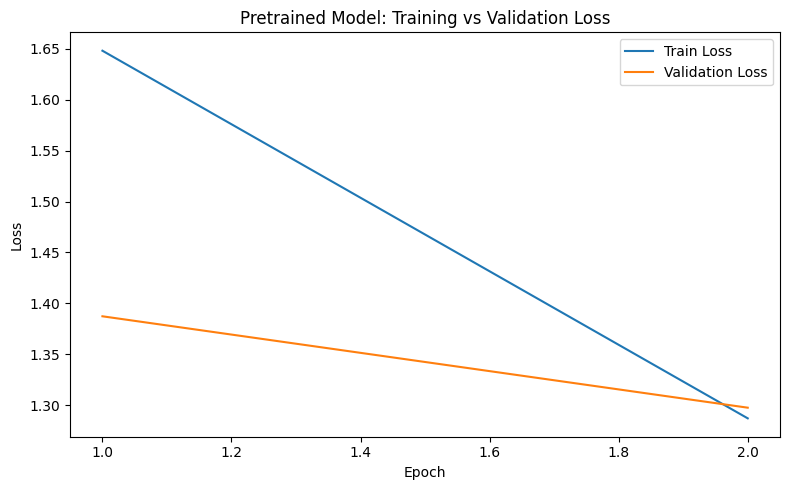

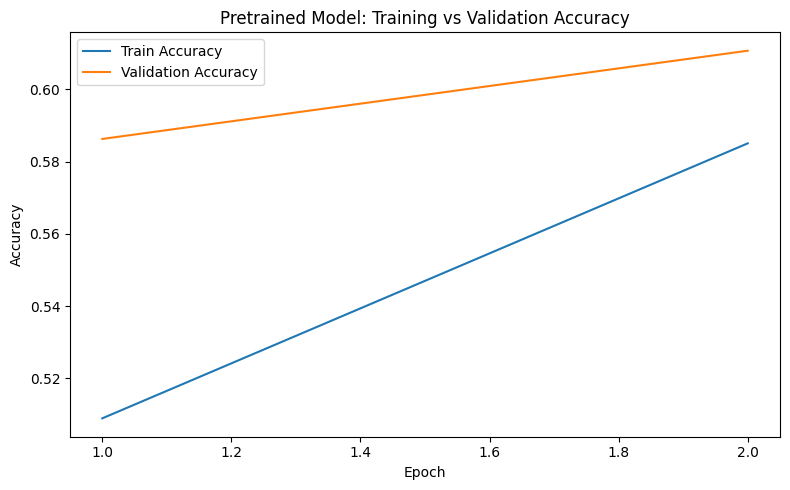

In [52]:
# ============================================================
# Step 8: Plot training history
# ============================================================

pretrained_history_df = pd.DataFrame(pretrained_history.history)

plt.figure(figsize=(8, 5))
plt.plot(pretrained_history_df.index + 1, pretrained_history_df["loss"], label="Train Loss")
plt.plot(pretrained_history_df.index + 1, pretrained_history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrained Model: Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(pretrained_history_df.index + 1, pretrained_history_df["accuracy"], label="Train Accuracy")
plt.plot(pretrained_history_df.index + 1, pretrained_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Pretrained Model: Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Best Validation Epoch

As in the earlier sections, the key benchmark is the validation accuracy at the epoch with the minimum validation loss. This keeps the comparison consistent across all three models.

In [53]:
# ============================================================
# Step 9: Best validation epoch summary
# ============================================================

pretrained_best_epoch = int(np.argmin(pretrained_history_df["val_loss"])) + 1
pretrained_best_val_loss = float(pretrained_history_df["val_loss"].min())
pretrained_best_val_acc = float(
    pretrained_history_df.loc[pretrained_best_epoch - 1, "val_accuracy"]
)

print("Best epoch (by minimum validation loss):", pretrained_best_epoch)
print(f"Best validation loss: {pretrained_best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {pretrained_best_val_acc:.4f}")

Best epoch (by minimum validation loss): 2
Best validation loss: 1.2978
Validation accuracy at best epoch: 0.6107


### Validation and Test Metrics

We evaluate the pretrained model on the validation and test sets using the same metrics as before, including accuracy and macro-F1. This makes it easier to judge whether transfer learning improved the results in a meaningful way.

In [54]:
# ============================================================
# Step 10: Validation and test metrics
# ============================================================

# Validation predictions
pretrained_val_logits = pretrained_model.predict(pretrained_val_ds, verbose=0)
pretrained_val_pred = np.argmax(pretrained_val_logits, axis=1)
pretrained_val_true = val_df["label"].to_numpy()

pretrained_val_accuracy = accuracy_score(pretrained_val_true, pretrained_val_pred)
pretrained_val_macro_f1 = f1_score(
    pretrained_val_true,
    pretrained_val_pred,
    average="macro"
)

# Test predictions
pretrained_test_logits = pretrained_model.predict(pretrained_test_ds, verbose=0)
pretrained_test_pred = np.argmax(pretrained_test_logits, axis=1)
pretrained_test_true = test_df["label"].to_numpy()

pretrained_test_accuracy = accuracy_score(pretrained_test_true, pretrained_test_pred)
pretrained_test_macro_f1 = f1_score(
    pretrained_test_true,
    pretrained_test_pred,
    average="macro"
)

# Keras evaluation for loss / accuracy
pretrained_test_loss, pretrained_test_acc_eval = pretrained_model.evaluate(
    pretrained_test_ds,
    verbose=0
)

print("Validation metrics")
print(f"Validation accuracy : {pretrained_val_accuracy:.4f}")
print(f"Validation macro-F1 : {pretrained_val_macro_f1:.4f}")

print("\nTest metrics")
print(f"Test loss           : {pretrained_test_loss:.4f}")
print(f"Test accuracy       : {pretrained_test_accuracy:.4f}")
print(f"Test macro-F1       : {pretrained_test_macro_f1:.4f}")

Validation metrics
Validation accuracy : 0.6107
Validation macro-F1 : 0.5486

Test metrics
Test loss           : 1.2780
Test accuracy       : 0.6153
Test macro-F1       : 0.5475


### Compact Results Summary

This summary reports the main pretrained-model results in the same format used earlier for the baseline and custom models.

In [55]:
# ============================================================
# Step 11: Compact pretrained-model results summary
# ============================================================

pretrained_results = pd.DataFrame([{
    "epochs_trained": pretrained_epochs_trained,
    "runtime_sec": round(pretrained_runtime_sec, 2),
    "best_epoch_by_val_loss": pretrained_best_epoch,
    "best_val_loss": round(pretrained_best_val_loss, 4),
    "val_accuracy_at_best_loss": round(pretrained_best_val_acc, 4),
    "val_macro_f1": round(pretrained_val_macro_f1, 4),
    "test_loss": round(pretrained_test_loss, 4),
    "test_accuracy": round(pretrained_test_accuracy, 4),
    "test_macro_f1": round(pretrained_test_macro_f1, 4)
}])

display(pretrained_results)

,epochs_trained,runtime_sec,best_epoch_by_val_loss,best_val_loss,val_accuracy_at_best_loss,val_macro_f1,test_loss,test_accuracy,test_macro_f1
0,2,473.37,2,1.2978,0.6107,0.5486,1.278,0.6153,0.5475


### Compare the Pretrained Model to the Earlier Models

The final comparison makes it easier to see whether transfer learning improved validation and test performance, whether it converged more quickly, and whether the additional computational cost was justified.

In [56]:
# ============================================================
# Step 12: Baseline vs custom vs pretrained comparison
# ============================================================

comparison_pretrained_df = pd.DataFrame([
    {
        "model": "Baseline",
        "epochs_trained": int(baseline_results.loc[0, "epochs_trained"]),
        "runtime_sec": float(baseline_results.loc[0, "runtime_sec"]),
        "best_epoch_by_val_loss": int(baseline_results.loc[0, "best_epoch_by_val_loss"]),
        "best_val_loss": float(baseline_results.loc[0, "best_val_loss"]),
        "val_accuracy_at_best_loss": float(baseline_results.loc[0, "val_accuracy_at_best_loss"]),
        "val_macro_f1": float(baseline_results.loc[0, "val_macro_f1"]),
        "test_loss": float(baseline_results.loc[0, "test_loss"]),
        "test_accuracy": float(baseline_results.loc[0, "test_accuracy"]),
        "test_macro_f1": float(baseline_results.loc[0, "test_macro_f1"])
    },
    {
        "model": "Custom",
        "epochs_trained": int(custom_results.loc[0, "epochs_trained"]),
        "runtime_sec": float(custom_results.loc[0, "runtime_sec"]),
        "best_epoch_by_val_loss": int(custom_results.loc[0, "best_epoch_by_val_loss"]),
        "best_val_loss": float(custom_results.loc[0, "best_val_loss"]),
        "val_accuracy_at_best_loss": float(custom_results.loc[0, "val_accuracy_at_best_loss"]),
        "val_macro_f1": float(custom_results.loc[0, "val_macro_f1"]),
        "test_loss": float(custom_results.loc[0, "test_loss"]),
        "test_accuracy": float(custom_results.loc[0, "test_accuracy"]),
        "test_macro_f1": float(custom_results.loc[0, "test_macro_f1"])
    },
    {
        "model": "Pretrained",
        "epochs_trained": pretrained_epochs_trained,
        "runtime_sec": round(pretrained_runtime_sec, 2),
        "best_epoch_by_val_loss": pretrained_best_epoch,
        "best_val_loss": round(pretrained_best_val_loss, 4),
        "val_accuracy_at_best_loss": round(pretrained_best_val_acc, 4),
        "val_macro_f1": round(pretrained_val_macro_f1, 4),
        "test_loss": round(pretrained_test_loss, 4),
        "test_accuracy": round(pretrained_test_accuracy, 4),
        "test_macro_f1": round(pretrained_test_macro_f1, 4)
    }
])

display(comparison_pretrained_df)

,model,epochs_trained,runtime_sec,best_epoch_by_val_loss,best_val_loss,val_accuracy_at_best_loss,val_macro_f1,test_loss,test_accuracy,test_macro_f1
0,Baseline,14,115.52,9,1.7746,0.5355,0.4582,1.7512,0.5477,0.4679
1,Custom,9,163.14,4,1.7336,0.5264,0.4562,1.7225,0.5317,0.4581
2,Pretrained,2,473.37,2,1.2978,0.6107,0.5486,1.2780,0.6153,0.5475


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?



**4.1:**

For the pretrained model, we chose DistilBERT. We picked it because it felt like a practical middle ground: it is smaller and easier to run than full BERT, but it still brings in much stronger language understanding than the earlier models. That matters on a dataset like HuffPost, where a lot of the categories are close to one another and the model often has to rely on subtle wording rather than obvious topic words. So DistilBERT seemed like the right choice for testing whether transfer learning could give a real advantage without making the experiment too heavy to manage.

2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

**4.2:**

We used a partial fine-tuning strategy rather than fully training every part of the transformer. The lower parts of the model were kept fixed, while the upper transformer layers and the classification head were allowed to update during training. We chose that approach because it gave us a balance between performance and practicality. We still wanted the model to adapt to the HuffPost task, but we did not want to make training unnecessarily expensive or unstable. Since the pretrained model already starts with strong language knowledge, it made sense to adjust only the parts that were most likely to matter for the final classification task.



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

**4.3:**

The pretrained model gave the best results of the three. Its best validation loss came at epoch 2, where it reached a validation accuracy of 0.6107 and a validation macro-F1 of 0.5486. On the test set, it achieved an accuracy of 0.6153 and a macro-F1 of 0.5475. This was a clear improvement over both the baseline and the custom GRU model. The pretrained model seems to have handled the overlapping categories better and made better use of short, sometimes ambiguous news text than the models trained entirely from scratch.



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

**4.4:**

The pretrained model was clearly the most expensive one to train. Even though it only ran for 2 epochs, it still took 473.37 seconds, compared with 115.52 seconds for the baseline and 163.14 seconds for the custom model. It also required more memory, which is not surprising for a transformer model. Still, this was one of those cases where the extra cost felt justified. The performance gain was large, and the model reached its best result very quickly. So while it was heavier to run, it was also the only model that gave a strong enough improvement to make that extra cost feel worthwhile.



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

## Problem 5: Comparative Evaluation and Discussion

In this final section, we bring the three models together and compare them more directly. The goal is not just to say which model got the highest score, but also to look at what each model gave us in terms of speed, complexity, and overall behavior. This part helps us decide which model makes the most sense to carry forward into the final report.

### Final Comparison Table

To compare the models fairly, we summarize the main results from the baseline, custom, and pretrained models in one table. This includes validation accuracy, test accuracy, macro-F1, training time, and parameter count.

In [57]:
# ============================================================
# Problem 5 - Final comparison table
# ============================================================

final_comparison_df = pd.DataFrame([
    {
        "model": "Baseline",
        "params": baseline_model.count_params(),
        "epochs_trained": int(baseline_results.loc[0, "epochs_trained"]),
        "runtime_sec": float(baseline_results.loc[0, "runtime_sec"]),
        "val_accuracy": float(baseline_results.loc[0, "val_accuracy_at_best_loss"]),
        "val_macro_f1": float(baseline_results.loc[0, "val_macro_f1"]),
        "test_accuracy": float(baseline_results.loc[0, "test_accuracy"]),
        "test_macro_f1": float(baseline_results.loc[0, "test_macro_f1"])
    },
    {
        "model": "Custom",
        "params": custom_model.count_params(),
        "epochs_trained": int(custom_results.loc[0, "epochs_trained"]),
        "runtime_sec": float(custom_results.loc[0, "runtime_sec"]),
        "val_accuracy": float(custom_results.loc[0, "val_accuracy_at_best_loss"]),
        "val_macro_f1": float(custom_results.loc[0, "val_macro_f1"]),
        "test_accuracy": float(custom_results.loc[0, "test_accuracy"]),
        "test_macro_f1": float(custom_results.loc[0, "test_macro_f1"])
    },
    {
        "model": "Pretrained",
        "params": pretrained_model.count_params(),
        "epochs_trained": int(pretrained_results.loc[0, "epochs_trained"]),
        "runtime_sec": float(pretrained_results.loc[0, "runtime_sec"]),
        "val_accuracy": float(pretrained_results.loc[0, "val_accuracy_at_best_loss"]),
        "val_macro_f1": float(pretrained_results.loc[0, "val_macro_f1"]),
        "test_accuracy": float(pretrained_results.loc[0, "test_accuracy"]),
        "test_macro_f1": float(pretrained_results.loc[0, "test_macro_f1"])
    }
])

display(final_comparison_df.sort_values("test_accuracy", ascending=False))

,model,params,epochs_trained,runtime_sec,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
2,Pretrained,66394409,2,473.37,0.6107,0.5486,0.6153,0.5475
0,Baseline,1926825,14,115.52,0.5355,0.4582,0.5477,0.4679
1,Custom,2953129,9,163.14,0.5264,0.4562,0.5317,0.4581


### Simple Visual Comparison

This quick chart makes it easier to compare the models side by side on the most important test metrics.

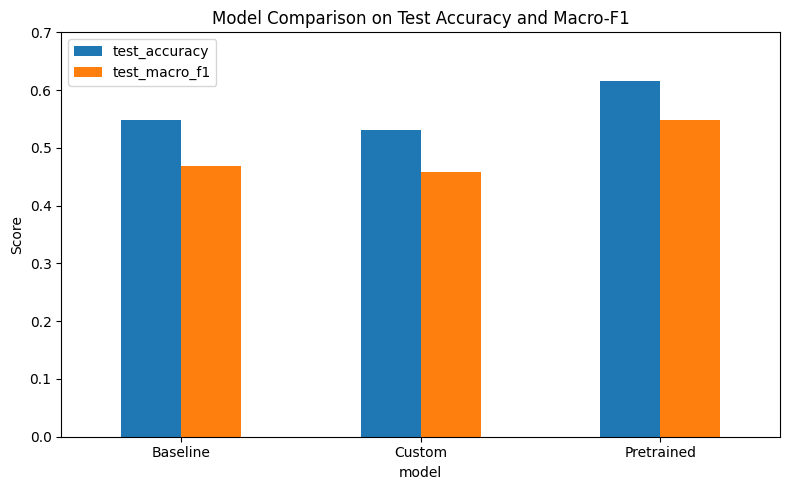

In [58]:
# ============================================================
# Problem 5 - Quick comparison chart
# ============================================================

plot_df = final_comparison_df.set_index("model")[["test_accuracy", "test_macro_f1"]]

plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Model Comparison on Test Accuracy and Macro-F1")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)
plt.tight_layout()
plt.show()

### Looking at Difficult Examples

To better understand model behavior, it is helpful to look at examples that were still misclassified. The next cell creates a small table of test examples where the pretrained model made mistakes.

In [59]:
# ============================================================
# Problem 5 - Inspect some misclassified examples
# ============================================================

error_df = test_df.reset_index(drop=True).copy()
error_df["true_label"] = [id_to_label[i] for i in pretrained_test_true]
error_df["pred_label"] = [id_to_label[i] for i in pretrained_test_pred]
error_df["correct"] = error_df["true_label"] == error_df["pred_label"]

misclassified_examples = error_df.loc[~error_df["correct"], ["text", "true_label", "pred_label"]].head(10)

display(misclassified_examples)

,text,true_label,pred_label
4,Man In Gorilla Suit Finishes London Marathon A...,THE WORLDPOST,GOOD NEWS
10,The Rise Of Polyamory: So What If Celebrities ...,DIVORCE,WEDDINGS
11,Guilty Of Good Grammar: You're Right And Your ...,RELIGION,ARTS & CULTURE
12,My Husband Saved His Life [SEP] Aside from my ...,PARENTING,FIFTY
13,"Cooking Off the Cuff: Peas, Tomatoes, Indian S...",TASTE,FOOD & DRINK
15,Multiple Victims Hospitalized After Powerful E...,CRIME,ENVIRONMENT
16,Leslie Perlow: Why You're Sleeping With Your S...,WELLNESS,TECH
19,Alex Trebek Mocks 'Jeopardy!' Contestants' Com...,ENTERTAINMENT,COMEDY
21,How to Squelch the Anti-Abortion Clause of the...,POLITICS,IMPACT
24,Slowing the Brain Drain in Central Africa to P...,GREEN,WORLDPOST


### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

**5.1:**

When we compare the three models side by side, the pretrained DistilBERT model is the clear winner. It had the strongest validation and test performance, with a test accuracy of 0.6153 and a test macro-F1 of 0.5475. The baseline came next, with 0.5477 test accuracy and 0.4679 macro-F1, and the custom GRU model was slightly behind that at 0.5317 test accuracy and 0.4581 macro-F1. What seems most important here is not just that the pretrained model scored highest, but why it did. It came in with language knowledge that the other two models had to learn from scratch, and that gave it a real advantage on short text and overlapping categories.





2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

**5.2:**

The trade-offs became pretty clear once the three models were placed next to each other. The baseline was the easiest and fastest to train, and it gave a decent starting result without much cost. The custom model was more complex and took longer, but that added complexity did not really pay off in the final metrics. The pretrained model was the most expensive in terms of time and memory, but it was also the only one that produced a strong improvement. So the lesson here is that extra complexity is only worth it when it leads to a real gain. In this notebook, that happened with transfer learning, not with the custom GRU.



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

**5.3:**

The hardest examples were the ones where the labels were already close in meaning. Categories such as ARTS, ARTS & CULTURE, CULTURE & ARTS, WORLD NEWS, WORLDPOST, STYLE, and TASTE were still difficult because the language used in those categories can overlap a lot. That becomes even harder when the input is just a short headline or a very brief description. So the main challenge across all three models was not recognizing broad topics, but drawing fine boundaries between categories that already look similar to a human reader as well. That is probably why those classes continued to be difficult even when the overall model improved.



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


**5.4:**

Based on the results from this milestone, we would move forward with the pretrained DistilBERT model. It performed best by a clear margin, so it gives us the strongest base to build on for the final report. At this point, we would rather improve that model than start over with a different architecture. The next steps would be to tune it more carefully, especially the learning rate and the fine-tuning setup, and to spend more time looking closely at the categories that were still being confused. We would also want to do more targeted error analysis so that the next round of changes is based on what the model is actually getting wrong, not just on guesswork.



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question:**

We used generative AI tools mainly to help with organization, wording, and revision of the notebook. In particular, it helped us check whether our answers were aligned with the milestone questions, improve the clarity of markdown explanations and code comments. We did not use AI to generate the modeling results themselves. The preprocessing, model building, training, evaluation, and comparison of results were still based on our own code and notebook outputs. Also we used AI support while working through some Google Colab issues, especially around package installation, runtime restarts, and compatibility problems that came up during the pretrained model section.
